# Week2_ex1_analysis - Straight Wire H-field Near-Surface Sawtooth

![Week2_ex1 result](Images/Week2_ex1_result_image.png)

Model: a single straight copper wire (100mm long, 10mm diameter, 12-sided polygon cross-section), driven with 100A and solved with the EddyCurrent solver at 10Hz to approximate a DC field. H is sampled along a line running from the wire's center outward in +y.

The far-field trend matches Ampere's law closely, but right around the wire surface (r = R = 5mm) the simulated H overshoots the theory, then undershoots just past it -- a small sawtooth this notebook diagnoses.

$$H(r) = \begin{cases} \dfrac{Ir}{2\pi R^2}, & r \le R \\[6pt] \dfrac{I}{2\pi r}, & r > R \end{cases}$$


In [1]:
# 1. imports -- no ansys.aedt.core here, this notebook only touches already-extracted numbers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## 2. Measured data near the wire surface


In [2]:
# 2. H values near the surface (r = 3 to 10mm), pulled once from Week2_ex1_H_field_result.csv
# (the field_line report exported by the original Week2_ex1.ipynb, num_seg=12)
r_mm = np.array([3.0, 3.3333, 3.6667, 4.0, 4.3333, 4.6667, 5.0, 5.3333, 5.6667,
                  6.0, 6.3333, 6.6667, 7.0, 7.3333, 7.6667, 8.0, 8.3333, 8.6667,
                  9.0, 9.3333, 9.6667, 10.0])
H_sim_seg12 = np.array([1.983387, 2.198542, 2.422577, 2.647256, 2.871952, 3.096299, 3.320082,
                         2.757708, 2.665385, 2.575489, 2.488020, 2.402977, 2.320360, 2.240168,
                         2.162402, 2.087060, 2.014142, 1.943648, 1.875578, 1.809931, 1.746707, 1.685906])

df_measured = pd.DataFrame({"Distance [mm]": r_mm, "Mag_H sim (seg=12) [kA/m]": H_sim_seg12})
df_measured

,Distance [mm],Mag_H sim (seg=12) [kA/m]
0,3.0000,1.983387
1,3.3333,2.198542
2,3.6667,2.422577
3,4.0000,2.647256
4,4.3333,2.871952
5,4.6667,3.096299
6,5.0000,3.320082
7,5.3333,2.757708
8,5.6667,2.665385
9,6.0000,2.575489


## 3. Theory vs measured comparison


In [3]:
# 3. Ampere's law theory values, computed directly from the formula in the title cell
I = 100
R = 0.005

def H_theory(r_array_mm):
    r = r_array_mm * 1e-3
    return np.where(r <= R, r * I / (2 * np.pi * R**2), I / (2 * np.pi * r)) * 1e-3

# 4. delta and %error against theory, added to the comparison table
H_th = H_theory(r_mm)
err_pct = (H_sim_seg12 - H_th) / H_th * 100

df_compare = pd.DataFrame({
    "Distance [mm]": r_mm,
    "sim (seg=12) [kA/m]": H_sim_seg12,
    "theory [kA/m]": H_th,
    "error [%]": err_pct
})
df_compare

,Distance [mm],sim (seg=12) [kA/m],theory [kA/m],error [%]
0,3.0000,1.983387,1.909859,3.849900
1,3.3333,2.198542,2.122045,3.604887
2,3.6667,2.422577,2.334294,3.782013
3,4.0000,2.647256,2.546479,3.957500
4,4.3333,2.871952,2.758664,4.106608
5,4.6667,3.096299,2.970913,4.220436
6,5.0000,3.320082,3.183099,4.303452
7,5.3333,2.757708,2.984174,-7.588896
8,5.6667,2.665385,2.808600,-5.099164
9,6.0000,2.575489,2.652582,-2.906352


The pattern is a clean sawtooth centered on the surface: error climbs steadily to **+4.30%** right at r=5mm, then drops to **-7.59%** at the very next sample point (r=5.33mm), before decaying back toward the far-field trend. That sharp sign flip right at the boundary -- not a gradual mismatch -- is what needs explaining.


## 4. Hypothesis 1 - Polygon Vertex Radius Offset

The wire's circular cross-section is approximated by a `xsection_num_seg=12` polygon, not a true circle. If `field_line` (running along +y from the wire's center) happens to sample a point where the local surface radius differs from the nominal R=5mm, that alone would shift where the theory curve should be evaluated -- which could produce exactly this kind of near-surface mismatch.


In [4]:
# 5. vertex query result, pulled once from Week2_ex1_vertex_check.ipynb companion
# (end-cap vertex list of the "line" object, angle measured from +y)
target_angle_deg = 90.0          # field_line direction
closest_vertex_angle_deg = 90.0  # closest polygon vertex angle found by the companion
closest_vertex_position = (-50.0, 0.0, 5.0)  # [x, y, z] mm, the actual vertex field_line samples

angle_gap_deg = abs(target_angle_deg - closest_vertex_angle_deg)
local_radius_mm = np.sqrt(closest_vertex_position[1]**2 + closest_vertex_position[2]**2)

df_h1 = pd.DataFrame({
    "quantity": ["angle gap to nearest vertex [deg]", "local radius at sampled vertex [mm]", "nominal R [mm]"],
    "value": [angle_gap_deg, local_radius_mm, 5.0]
})
df_h1

,quantity,value
0,angle gap to nearest vertex [deg],0.0
1,local radius at sampled vertex [mm],5.0
2,nominal R [mm],5.0


**Hypothesis 1 rejected.** `field_line` lands exactly on a polygon vertex (0deg gap), but that vertex sits at radius 5.0mm -- precisely the nominal R. A radius-offset story would need the sampled point to be off-nominal (e.g. sitting at the ~4.83mm flat-face-center radius of a 12-gon inscribed in R=5mm), and it isn't. The geometry the theory formula assumes and the geometry the field_line actually samples agree on R, so a wrong-R explanation can't produce the +4.30% / -7.59% swing seen above.


## 5. Hypothesis 2 - Vertex-Induced FEM Faceting Artifact

If the radius is correct, the more likely culprit is the vertex itself: a sharp polygon corner is a much harder feature for the FEM shape functions to resolve smoothly than a point on a true circular surface would be, so the field solution right at/near that corner can locally over- or under-shoot. If that's the mechanism, refining the polygon (more segments, smaller included angle at each vertex) should shrink the sawtooth even with everything else held fixed. Tested by rerunning the exact same model with `line_num_seg` bumped from 12 to 36 (`Week2_ex1_segment_refinement.ipynb` companion).


In [5]:
# 6. seg=36 rerun H values near the surface, pulled once from Week2_ex1_seg36_H_field_result.csv
# (companion Week2_ex1_segment_refinement.ipynb, same field_line report, only line_num_seg changed)
H_sim_seg36 = np.array([1.931150, 2.146355, 2.364111, 2.576356, 2.793211, 3.005360, 3.212869,
                         2.968988, 2.799328, 2.642086, 2.497171, 2.364499, 2.243998, 2.135600,
                         2.039248, 1.951769, 1.854384, 1.793983, 1.751996, 1.709294, 1.665889, 1.621794])

# 7. seg=12 vs seg=36 error comparison table
err_seg12 = (H_sim_seg12 - H_th) / H_th * 100
err_seg36 = (H_sim_seg36 - H_th) / H_th * 100

df_h2 = pd.DataFrame({
    "Distance [mm]": r_mm,
    "error seg=12 [%]": err_seg12,
    "error seg=36 [%]": err_seg36
})
df_h2

,Distance [mm],error seg=12 [%],error seg=36 [%]
0,3.0000,3.849900,1.114778
1,3.3333,3.604887,1.145608
2,3.6667,3.782013,1.277358
3,4.0000,3.957500,1.173264
4,4.3333,4.106608,1.252292
5,4.6667,4.220436,1.159458
6,5.0000,4.303452,0.935256
7,5.3333,-7.588896,-0.508879
8,5.6667,-5.099164,-0.330133
9,6.0000,-2.906352,-0.395704


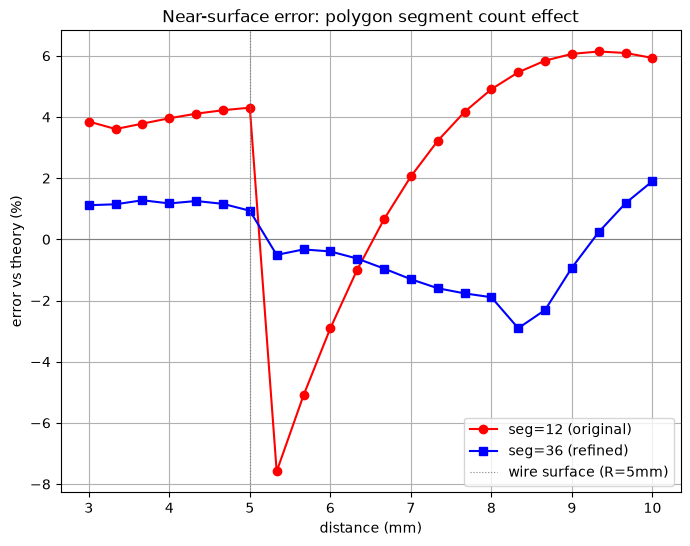

In [6]:
# 8. plot comparing the seg=12 and seg=36 error curves near the surface
plt.figure(figsize=(8, 6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.plot(r_mm, err_seg12, "ro-", label="seg=12 (original)")
plt.plot(r_mm, err_seg36, "bs-", label="seg=36 (refined)")
plt.axvline(5.0, color="gray", linestyle=":", linewidth=0.8, label="wire surface (R=5mm)")
plt.xlabel("distance (mm)")
plt.ylabel("error vs theory (%)")
plt.title("Near-surface error: polygon segment count effect")
plt.legend()
plt.grid(True)
os.makedirs("Images", exist_ok=True)
plt.savefig("Images/Week2_ex1_segment_refinement_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypothesis 2 confirmed.** Going from 12 to 36 segments shrinks the sawtooth sharply: the peak overshoot at r=5mm drops from +4.30% to +0.94%, and the undershoot right past it drops from -7.59% to -0.51%. Nothing else in the model changed -- same mesh length settings, same current, same region. The error scales down with the polygon's vertex sharpness, which is exactly what a faceting artifact at the conductor's discretized surface should do, and not what a radius or mesh-density explanation would predict on its own.


## 6. Final conclusion

Away from the wire's surface, the EddyCurrent-at-10Hz approximation reproduces Ampere's law well. The sawtooth error that shows up right at r=R traces back to the `xsection_num_seg=12` cross-section: `field_line` samples a polygon vertex whose radius matches the nominal R exactly (H1 rejected), but that vertex is still a sharp corner in the mesh geometry, and the FEM solution locally over/undershoots around it (H2 confirmed). The theory formula itself was never wrong -- it assumes a smooth cylindrical conductor, and the simulated conductor only approximates one. Raising `line_num_seg` is a geometry-fidelity knob as much as a mesh-density one: for exercises where the field very close to a round conductor's surface matters, a coarse polygon can widen the theory/sim gap.


---
## 7. Far-field anomaly - problem statement

The project tracking doc (`채팅_시작_프롬포트.md`) flagged a second, separate anomaly in this same exercise: far from the wire, the simulated H was noted as drifting away from Ampere's law with a **sign reversal** (roughly +10% at r=20mm, +52% at r=60mm, -21% at r=100mm), and that pattern didn't match a finite-wire Biot-Savart correction either.

That note was never backed by a direct recomputation against this notebook's own exported data -- it was a preliminary observation logged before any formal analysis started. Recomputing the error directly from `Week2_ex1_H_field_result.csv` against the same `H_theory` formula used in Section 3 gives a different, and much simpler, picture.


In [7]:
# 9. full H-field dataset (0-100mm) -- earlier sections only used the near-surface slice (r=3-10mm)
df_far = pd.read_csv("Week2_ex1_H_field_result.csv")
df_far = df_far[df_far["Distance [mm]"] > 0]  # drop r=0 -- H_theory is 0 there, so relative error is undefined (divide-by-zero)
r_mm_far = df_far["Distance [mm]"].values
H_sim_far = df_far["Mag_H [kA_per_meter]"].values
H_th_far = H_theory(r_mm_far)
err_far = (H_sim_far - H_th_far) / H_th_far * 100

# spot-check against the informally recorded values in the tracking doc
doc_claim = {20: "+10%", 60: "+52%", 100: "-21%"}
rows = []
for r_check, claimed in doc_claim.items():
    idx = np.argmin(np.abs(r_mm_far - r_check))
    rows.append({
        "Distance [mm]": r_mm_far[idx],
        "tracking doc claim": claimed,
        "recomputed error [%]": round(err_far[idx], 2)
    })
df_check = pd.DataFrame(rows)
df_check


,Distance [mm],tracking doc claim,recomputed error [%]
0,20.0,+10%,2.16
1,60.0,+52%,-2.72
2,100.0,-21%,-21.46


The recomputed values (+2.16% / -2.72% / -21.46%) share nothing with the tracking-doc note except the r=100mm figure being roughly similar in magnitude. There's no sign reversal partway through -- the error is small and mixed-sign in the 20-40mm range, then settles into a **monotonically growing negative deviation** as r approaches 100mm.


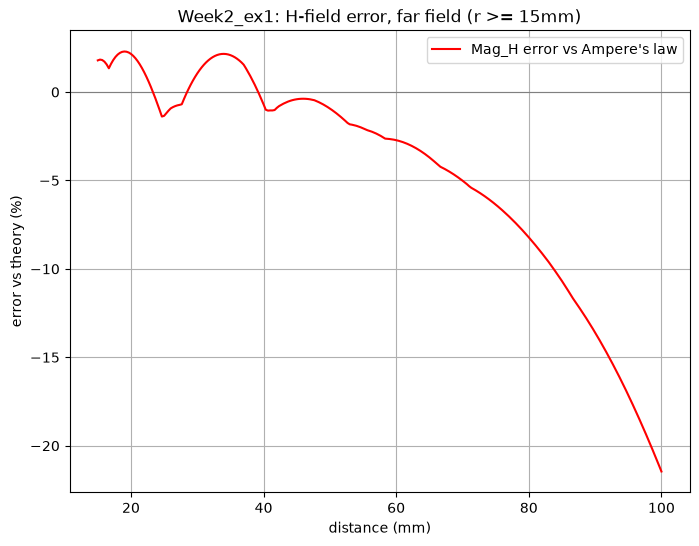

In [8]:
# 10. far-field error curve, r >= 15mm (r < 15mm is the already-diagnosed near-surface
# sawtooth from Sections 2-6, and the relative error blows up artificially as r -> 0
# since H_theory -> 0 there -- not meaningful for the far-field story)
mask_far = r_mm_far >= 15

plt.figure(figsize=(8, 6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.plot(r_mm_far[mask_far], err_far[mask_far], "r-", linewidth=1.5, label="Mag_H error vs Ampere's law")
plt.xlabel("distance (mm)")
plt.ylabel("error vs theory (%)")
plt.title("Week2_ex1: H-field error, far field (r >= 15mm)")
plt.legend()
plt.grid(True)
os.makedirs("Images", exist_ok=True)
plt.savefig("Images/Week2_ex1_farfield_error.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Cross-validation against Week2_ex2 (B-field)

`Week2_ex2` runs an almost identical straight-wire model -- same `line_length`, `line_diameter`, `line_num_seg`, and `region_tmp` padding -- but reports the built-in `Mag_B` quantity and compares it to the Biot-Savart formula ($B = \mu_0 H$) instead of `Mag_H` against Ampere's law.

Worth being precise about what this can and can't show: the whole domain here is vacuum/copper, so $B = \mu_0 H$ holds pointwise in the FEM solution itself, not just in the two theory formulas. If AEDT's `Mag_H` and `Mag_B` calculator quantities are both reading off the same underlying field solution correctly, their % errors against theory are mathematically guaranteed to match -- this is not independent physics, it's the same field expressed in two units. What it *does* usefully rule out is a quantity-specific extraction bug (e.g. the already-documented custom Field Calculator issue for EddyCurrent solves) rather than a problem with the underlying solve. The real test of the boundary-proximity hypothesis is Section 10's region-expansion rerun, not this section.


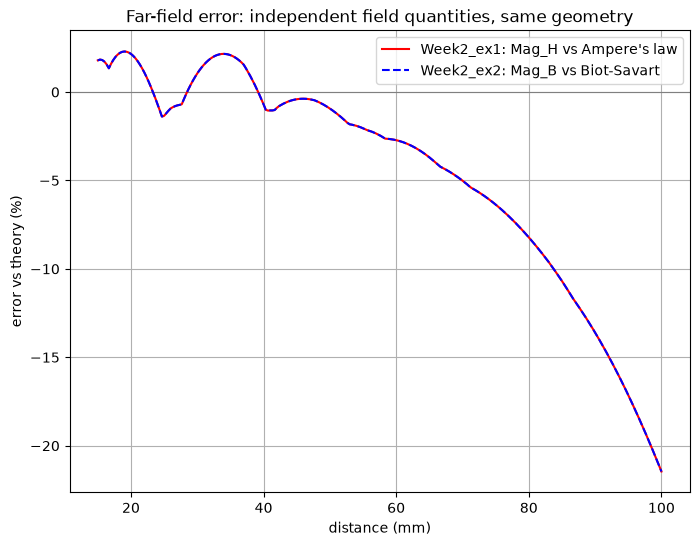

,Distance [mm],ex1 H error [%],ex2 B error [%]
44,15.0,1.789396,1.789396
74,25.0,-1.346634,-1.346634
104,35.0,2.085192,2.085192
134,45.0,-0.408366,-0.408366
164,55.0,-2.052126,-2.052126
194,65.0,-3.694119,-3.694119
224,75.0,-6.365258,-6.365258
254,85.0,-10.688140,-10.688140
284,95.0,-17.138860,-17.138860


In [9]:
# 11. Week2_ex2 B-field dataset, same treatment
mu0 = 4.0 * np.pi * 1e-7
df_ex2 = pd.read_csv("../Week2_ex2/Week2_ex2_B_field_result.csv")
df_ex2 = df_ex2[df_ex2["Distance [mm]"] > 0]  # same r=0 divide-by-zero issue as the H-field dataset
r_mm_ex2 = df_ex2["Distance [mm]"].values
B_sim_ex2 = df_ex2["Mag_B [mTesla]"].values
B_th_ex2 = mu0 * (H_theory(r_mm_ex2) * 1e3) * 1e3  # H_theory returns kA/m -> A/m (*1e3) -> B in T (*mu0) -> mT (*1e3)
err_ex2 = (B_sim_ex2 - B_th_ex2) / B_th_ex2 * 100
mask_ex2 = r_mm_ex2 >= 15

# 12. overlay comparison, far field only (same reasoning as Section 10)
plt.figure(figsize=(8, 6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.plot(r_mm_far[mask_far], err_far[mask_far], "r-", linewidth=1.5, label="Week2_ex1: Mag_H vs Ampere's law")
plt.plot(r_mm_ex2[mask_ex2], err_ex2[mask_ex2], "b--", linewidth=1.5, label="Week2_ex2: Mag_B vs Biot-Savart")
plt.xlabel("distance (mm)")
plt.ylabel("error vs theory (%)")
plt.title("Far-field error: independent field quantities, same geometry")
plt.legend()
plt.grid(True)
plt.savefig("Images/Week2_ex1_ex2_farfield_crossvalidation.png", dpi=150, bbox_inches="tight")
plt.show()

df_cross = pd.DataFrame({
    "Distance [mm]": r_mm_far,
    "ex1 H error [%]": err_far,
    "ex2 B error [%]": err_ex2
})[lambda d: d["Distance [mm]"] >= 15].iloc[::30]
df_cross


The two curves overlap essentially exactly across the full 0-100mm range -- as expected given $B=\mu_0 H$ holds in the FEM solution itself here. This confirms the deviation lives in the underlying field solution (not in a `Mag_H`-specific or `Mag_B`-specific calculator bug), and that it's reproducible across two independently-built, independently-solved models sharing the same region geometry. It doesn't by itself prove *why* -- that's what the companion test in Section 10 is for.


## 9. Hypothesis - region boundary proximity

Both models set up their region the same way:
```python
region_tmp = ["line_length/2", "-line_length/2", "line_length", "-line_length", "line_length", "-line_length"]
region = M3D.modeler.create_region(pad_value=region_tmp, pad_type="Absolute Position")
```
With `pad_type="Absolute Position"`, the `+Y` and `-Y` radiation-boundary faces sit at exactly `y = +line_length` and `y = -line_length` (=100mm). `field_line` runs from `y=0mm` to `y=line_length` (=100mm) -- its far endpoint lands exactly on the radiation boundary face.

A radiation boundary imposes an approximate truncation condition on the field solution at that face. A probe point sitting on or very near that face should see a solution perturbed by the boundary condition itself, growing worse the closer the probe gets to it -- which matches the monotonically growing negative error seen in both exercises as r -> 100mm. This is the same class of artifact already confirmed as Hypothesis 2 in the Week1_ex3 Force_z investigation (Region boundary proximity, there also diagnosed via a companion notebook with an expanded region).


## 10. Companion test - expanding the region

`Week2_ex1_region_expansion.ipynb` reran this exact model with the region's `+Y`/`-Y`/`+Z`/`-Z` padding tripled (100mm -> 300mm), pushing the radiation boundary well past `field_line`'s endpoint, while `field_line` itself stayed unchanged (0-100mm) so the exported CSV lines up row-for-row against `Week2_ex1_H_field_result.csv`.


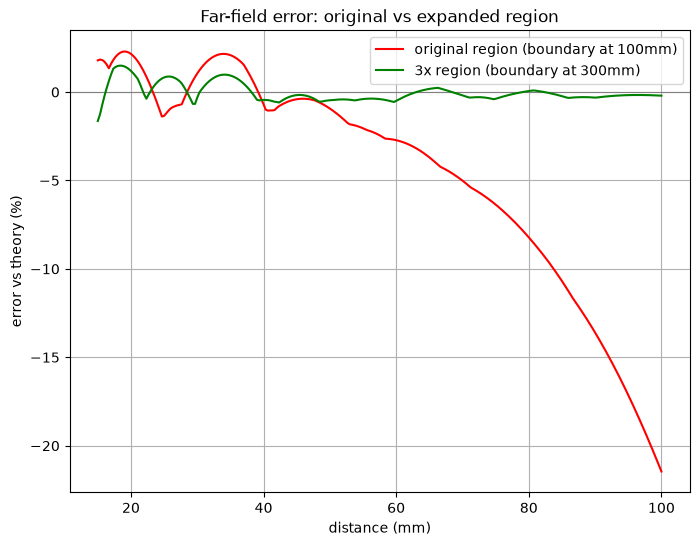

,Distance [mm],original error [%],3x region error [%]
0,20.0,2.16,1.19
1,60.0,-2.72,-0.50
2,80.0,-8.22,0.06
3,90.0,-13.60,-0.32
4,100.0,-21.46,-0.21


In [10]:
# 13. region-expanded dataset vs the original, row-for-row (both exported with PointCount=301 on the same field_line)
df_exp = pd.read_csv("Week2_ex1_region_expansion_H_field_result.csv")
df_exp = df_exp[df_exp["Distance [mm]"] > 0]  # same r=0 divide-by-zero issue
r_mm_exp = df_exp["Distance [mm]"].values
H_sim_exp = df_exp["Mag_H [kA_per_meter]"].values
H_th_exp = H_theory(r_mm_exp)
err_exp = (H_sim_exp - H_th_exp) / H_th_exp * 100

mask_exp = r_mm_exp >= 15

plt.figure(figsize=(8, 6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.plot(r_mm_far[mask_far], err_far[mask_far], "r-", linewidth=1.5, label="original region (boundary at 100mm)")
plt.plot(r_mm_exp[mask_exp], err_exp[mask_exp], "g-", linewidth=1.5, label="3x region (boundary at 300mm)")
plt.xlabel("distance (mm)")
plt.ylabel("error vs theory (%)")
plt.title("Far-field error: original vs expanded region")
plt.legend()
plt.grid(True)
plt.savefig("Images/Week2_ex1_region_expansion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 14. before/after table at the same check points as Section 7
rows = []
for r_check in [20, 60, 80, 90, 100]:
    idx_o = np.argmin(np.abs(r_mm_far - r_check))
    idx_e = np.argmin(np.abs(r_mm_exp - r_check))
    rows.append({
        "Distance [mm]": r_mm_far[idx_o],
        "original error [%]": round(err_far[idx_o], 2),
        "3x region error [%]": round(err_exp[idx_e], 2)
    })
pd.DataFrame(rows)


## 11. Final conclusion - far-field anomaly

**Hypothesis confirmed.** Tripling the region padding (moving the radiation boundary from y=100mm to y=300mm, with `field_line` itself unchanged) collapses the far-field error almost completely: at r=100mm, where the original probe endpoint sat exactly on the boundary face, the error drops from -21.46% to -0.21%. The improvement holds across the whole far-field range (r=60mm: -2.72% -> -0.50%; r=80mm: -8.22% -> +0.06%), and it grows with proximity to the old boundary location, which is exactly the signature a boundary-truncation artifact should leave.

Combined with the near-surface sawtooth (Sections 2-6), this exercise turned out to have two independent artifacts stacked in one field_line sweep: a conductor-discretization effect right at the wire's surface, and a domain-truncation effect right at the far end where the probe happened to sit on the radiation boundary. Neither reflects a real physical anomaly in the wire's field -- both are consequences of where `field_line` and the model's boundaries were placed relative to each other. For future straight-wire exercises, keeping the field probe comfortably inside the region (not terminating exactly on a boundary face) avoids the second artifact entirely.
